# Tugas Analisis Numerik: Menghitung Volume Kedua Lambung Perahu Katamaran

| | |
|---|---|
| **Nama** | Rafinda Mutiara Nurfitriati |
| **NPM** | 25083010012 |
| **Program Studi** | Sains Data |
| **Mata Kuliah** | Analisis Numerik |
| **Soal** | [perahu.pdf (GitHub)](https://github.com/jendralhxr/metnummatdis/blob/main/perahu.pdf) |
| **Sumber gambar** | [Desain dan Konstruksi Perahu Katamaran Fiberglass untuk Wisata Pancing (ResearchGate)](https://www.researchgate.net/publication/342077926_Desain_dan_Konstruksi_Perahu_Katamaran_Fiberglass_untuk_Wisata_Pancing) |

---

## 1. Pendahuluan dan Rumusan Masalah

Perahu katamaran memiliki dua lambung (*hull*) yang sejajar. Pada tugas ini diberikan gambar teknik perahu dalam tiga bagian: **tampak atas**, **tampak samping**, dan sebuah grid hijau putus-putus sebagai acuan skala. Tugasnya adalah **menghitung volume kedua lambung** dengan ketentuan dari soal:

1. Satu *dash* ditambah satu celah kosong pada garis grid sama dengan **5 + 5 cm = 10 cm**.
2. Lantai kapal dianggap **datar (tanpa keel)**, sehingga tampak depan setiap penampang lambung berupa **persegi panjang**.
3. Volume bagian ***reserve buoyancy*** (ujung buritan dan ujung haluan) **tidak dihitung**.

Karena bentuk lambung melengkung (lebarnya berubah di sepanjang lambung dan dasarnya naik di dekat haluan), volumenya tidak bisa dihitung dengan rumus balok sederhana. Masalah ini sangat cocok diselesaikan dengan **integrasi numerik**.

## 2. Pemodelan Matematis

Misalkan sumbu $x$ berjalan sepanjang lambung (dari buritan ke haluan). Di setiap posisi $x$, penampang melintang lambung adalah persegi panjang (sesuai asumsi lantai datar) dengan:

- **lebar** $w(x)$, diambil dari **tampak atas**,
- **tinggi** $h(x)$, diambil dari **tampak samping** (dari garis geladak sampai dasar lambung).

Sehingga luas penampang pada posisi $x$ adalah

$$A(x) = w(x)\,h(x).$$

Volume satu lambung adalah hasil integral luas penampang sepanjang lambung, **di antara kedua sekat *reserve buoyancy***, yaitu dari $x=a$ (sekat buritan) sampai $x=b$ (sekat haluan):

$$V_{\text{lambung}} = \int_{a}^{b} w(x)\,h(x)\,dx .$$

Karena kedua lambung pada gambar identik (bentuk dan ukurannya sama, diverifikasi pada bagian 9), volume total adalah

$$V_{\text{total}} = 2\,V_{\text{lambung}}.$$

Fungsi $w(x)$ dan $h(x)$ tidak tersedia dalam bentuk rumus, melainkan hanya berupa gambar. Oleh karena itu langkah kerjanya:

1. **Digitasi**: mengukur $w(x)$ dan $h(x)$ pada titik-titik $x_i$ dari gambar.
2. **Interpolasi** data diskret menjadi fungsi kontinu.
3. **Integrasi numerik** (Trapesium, Simpson 1/3, dan *adaptive quadrature*) lalu dibandingkan.
4. **Verifikasi konvergensi** dan **analisis ketidakpastian** hasil.

## 3. Penentuan Skala Gambar

Skala diambil dari **garis grid putus-putus**, bukan dari jarak antar garis grid. Hal ini penting: setelah diukur, jarak antar garis grid hijau adalah sekitar 71,1 piksel (pada rasterisasi 200 dpi), sedangkan satu periode *dash + celah* hanya sekitar 16,67 piksel. Jadi satu kotak grid ≈ 4,27 periode dash, **bukan** 10 cm. Kotak grid kira-kira berukuran 42,7 cm, sehingga kalau kotak dianggap 10 cm hasilnya akan salah jauh.

Ukuran satu periode dash adalah 6,0 pt (16,67 px pada 200 dpi) yang mewakili **10 cm**, sehingga

$$1\ \text{px}\ (200\ \text{dpi}) = \frac{10\ \text{cm}}{16{,}67} = 0{,}6\ \text{cm}.$$

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator, CubicSpline
from scipy.integrate import quad

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [77]:
# ---- Skala gambar (hasil pengukuran periode dash pada rasterisasi 200 dpi) ----
DASH_CM   = 10.0                    # 1 dash + 1 celah = 5 + 5 cm
DPI       = 200
DASH_PT   = 6.0                     # panjang satu periode dash dalam satuan pt (1 pt = 1/72 inci)
PX_PER_DASH = DASH_PT / 72 * DPI    # = 16.667 px
CM_PER_PX   = DASH_CM / PX_PER_DASH # = 0.6 cm/px

GRID_PX = 71.1                      # jarak antar garis grid hasil pengukuran (px)

print(f"Satu periode dash  = {PX_PER_DASH:.3f} px  -> 10 cm")
print(f"Skala              = {CM_PER_PX:.3f} cm/px")
print(f"Jarak antar grid   = {GRID_PX:.1f} px = {GRID_PX*CM_PER_PX:.1f} cm (~{GRID_PX/PX_PER_DASH:.2f} periode dash)")

Satu periode dash  = 16.667 px  -> 10 cm
Skala              = 0.600 cm/px
Jarak antar grid   = 71.1 px = 42.7 cm (~4.27 periode dash)


## 4. Digitasi Gambar

Gambar dirasterisasi dengan resolusi 200 dpi, lalu kontur lambung diekstrak dengan analisis piksel (bukan sekadar menebak dengan mata). Langkahnya:

1. **Piksel hijau** (grid) dibuang, hanya **piksel abu-abu gelap** (garis kontur lambung) yang dipakai.
2. **Lebar $w(x)$ dari tampak atas.** Untuk setiap kolom piksel $x$ dicari tepi atas dan tepi bawah kontur tiap lambung. Pusat (sumbu simetri) tiap lambung diestimasi dari bagian tengah lambung yang bersih. Setengah lebar diambil sebagai jarak tepi ke sumbu simetri, lalu median dari semua tepi yang valid (4 tepi: 2 lambung × 2 sisi) dipakai. Bagian yang tertutup balok melintang atau penyangga **dibuang** dari estimasi.
3. **Tinggi $h(x)$ dari tampak samping.** Garis atas lambung (garis geladak) berada pada ketinggian konstan, lalu tepi bawah kontur diambil per kolom piksel. Dasar dibatasi pada garis dasar datar karena garis grid paling bawah berimpit dengan dasar lambung.
4. **Batas integrasi** ditentukan dari posisi garis sekat *reserve buoyancy* di kiri (garis lengkung dekat buritan) dan di kanan (garis lurus dekat haluan).
5. Sampel diambil tiap **10 cm** (satu periode dash) di antara kedua sekat.

Kode digitasi saya sertakan di bawah ini agar proses dapat direproduksi. Secara bawaan sel ini **dinonaktifkan** (`RUN_DIGITIZATION = False`) supaya notebook tetap bisa dijalankan tanpa file PDF dan tanpa `poppler`; hasil digitasi sudah disimpan pada bagian 5.

In [78]:
RUN_DIGITIZATION = False      # True bila "perahu.pdf" ada di folder ini dan poppler-utils (pdftoppm) terpasang
PDF_PATH = "perahu.pdf"

def digitasi_lambung(png_path, cm_per_px=CM_PER_PX, step_cm=10.0):
    """Mengembalikan array [x_cm, lebar_cm, tinggi_cm] untuk titik-titik di antara kedua sekat."""
    import warnings
    from PIL import Image
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    im = np.array(Image.open(png_path).convert("RGB")).astype(int)
    s = im.shape[1] / 1456.0                       # koordinat acuan diukur pada tampilan lebar 1456 px
    dark = (im.max(2) < 175) & (abs(im[:, :, 0] - im[:, :, 1]) < 25) & (abs(im[:, :, 1] - im[:, :, 2]) < 25)
    D = lambda v: v * s

    def top(x, a, b):
        ys = np.where(dark[int(D(a)):int(D(b)), x])[0]
        return ys.min() + int(D(a)) if len(ys) else np.nan
    def bot(x, a, b):
        ys = np.where(dark[int(D(a)):int(D(b)), x])[0]
        return ys.max() + int(D(a)) if len(ys) else np.nan

    x_left, x_sekat_kiri, x_sekat_kanan = D(19.7), D(130.1), D(888.1)
    y_deck, y_dasar = D(642.5), D(765.7)

    # sumbu simetri tiap lambung dari zona tengah yang bersih
    zona = [int(D(v)) for v in range(300, 650, 10)]
    c_atas  = np.nanmedian([(top(x, 89, 200) + bot(x, 89, 200)) / 2 for x in zona])
    c_bawah = np.nanmedian([(top(x, 425, 540) + bot(x, 425, 540)) / 2 for x in zona])

    def setengah_lebar(xp):
        xd = xp / s
        balok  = (203 <= xd <= 221) or (722 <= xd <= 741)
        brace  = (203 <= xd <= 268) or (668 <= xd <= 742)
        label  = (60 <= xd <= 165)
        est = []
        if not balok and not label: est.append(c_atas - top(xp, 89, 200))
        if not balok:
            if not brace: est.append(c_bawah - top(xp, 425, 540))
            est.append(bot(xp, 425, 540) - c_bawah)
        if not balok and not brace: est.append(bot(xp, 89, 200) - c_atas)
        est = [e for e in est if e == e and e > 0]
        return np.median(est) if est else np.nan

    langkah = step_cm / cm_per_px
    n = int((x_sekat_kanan - x_sekat_kiri) / langkah)
    titik = [x_sekat_kiri + i * langkah for i in range(n + 1)] + [x_sekat_kanan]
    hasil = []
    for xp in titik:
        xi = int(round(xp))
        hw = np.nanmedian([setengah_lebar(xi + d) for d in range(-3, 4)])
        bw = np.nanmedian([bot(xi + d, 640, 772) for d in range(-3, 4)])
        bw = min(bw, y_dasar)
        hasil.append(((xp - x_left) * cm_per_px, 2 * hw * cm_per_px, (bw - y_deck) * cm_per_px))
    return np.array(hasil)

if RUN_DIGITIZATION:
    import subprocess, glob
    subprocess.run(["pdftoppm", "-png", "-r", "200", "-f", "1", "-l", "1", PDF_PATH, "raster"], check=True)
    png = sorted(glob.glob("raster*.png"))[0]
    hasil_digitasi = digitasi_lambung(png)
    print("Digitasi selesai:", hasil_digitasi.shape[0], "titik")
else:
    print("Digitasi dilewati; memakai data hasil digitasi yang tersimpan pada bagian 5.")

Digitasi dilewati; memakai data hasil digitasi yang tersimpan pada bagian 5.


## 5. Data Hasil Digitasi

Tabel berikut adalah hasil digitasi pada 70 titik dengan jarak 10 cm (titik terakhir tepat di sekat haluan, sehingga selang terakhir lebih pendek, yaitu sekitar 8,8 cm). Koordinat $x$ diukur dari ujung buritan lambung (paling kiri). Titik pertama ($x\approx100{,}3$ cm) adalah sekat *reserve buoyancy* buritan, dan titik terakhir ($x\approx789{,}1$ cm) adalah sekat *reserve buoyancy* haluan.

Nilai `NaN` pada $w$ berarti tepi lambung pada posisi tersebut tertutup balok melintang (*cross beam*) sehingga tidak bisa diukur langsung.

In [79]:
# Data hasil digitasi (satuan: cm). x diukur dari ujung buritan (kiri) lambung.
x_cm = np.array([
    100.3, 110.3, 120.3, 130.3, 140.3, 150.3, 160.3, 170.3, 180.3, 190.3,
    200.3, 210.3, 220.3, 230.3, 240.3, 250.3, 260.3, 270.3, 280.3, 290.3,
    300.3, 310.3, 320.3, 330.3, 340.3, 350.3, 360.3, 370.3, 380.3, 390.3,
    400.3, 410.3, 420.3, 430.3, 440.3, 450.3, 460.3, 470.3, 480.3, 490.3,
    500.3, 510.3, 520.3, 530.3, 540.3, 550.3, 560.3, 570.3, 580.3, 590.3,
    600.3, 610.3, 620.3, 630.3, 640.3, 650.3, 660.3, 670.3, 680.3, 690.3,
    700.3, 710.3, 720.3, 730.3, 740.3, 750.3, 760.3, 770.3, 780.3, 789.1,
])

# Lebar lambung w(x) dari tampak atas (NaN = tepi lambung tertutup balok/penyangga)
w_cm = np.array([
    74.4, 76.8, 78.0, 80.4, 81.6, 82.8, 84.6, np.nan, np.nan, 87.6,
    88.2, 88.8, 90.0, 90.0, 90.0, 90.6, 91.2, 91.2, 91.2, 91.2,
    91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2,
    91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2,
    91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 91.2, 90.6, 91.2,
    90.0, 90.0, 89.4, 88.8, np.nan, np.nan, 85.2, 84.0, 82.8, 81.6,
    79.2, 78.0, 75.6, 73.2, 70.8, 68.4, 66.0, 62.4, 59.4, 56.4,
])

# Tinggi lambung h(x) dari tampak samping (garis geladak sampai dasar datar)
h_cm = np.array([
    81.0, 85.2, 88.8, 92.4, 96.0, 99.0, 102.0, 105.0, 106.8, 109.2,
    111.6, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9,
    111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9,
    111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9, 111.9,
    111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6,
    111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6,
    111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6, 111.6,
])

df = pd.DataFrame({"x (cm)": x_cm, "lebar w (cm)": w_cm, "tinggi h (cm)": h_cm})
print(f"Jumlah titik data      : {len(df)}")
print(f"Data lebar yang hilang : {int(np.isnan(w_cm).sum())} titik  (x = {x_cm[np.isnan(w_cm)]} cm)")
print(f"Data tinggi yang hilang: {int(np.isnan(h_cm).sum())} titik")
print()
print(df.head(8).to_string(index=False))
print("   ...")
print(df.tail(5).to_string(index=False))

Jumlah titik data      : 70
Data lebar yang hilang : 4 titik  (x = [170.3 180.3 640.3 650.3] cm)
Data tinggi yang hilang: 0 titik

 x (cm)  lebar w (cm)  tinggi h (cm)
100.300        74.400         81.000
110.300        76.800         85.200
120.300        78.000         88.800
130.300        80.400         92.400
140.300        81.600         96.000
150.300        82.800         99.000
160.300        84.600        102.000
170.300           NaN        105.000
   ...
 x (cm)  lebar w (cm)  tinggi h (cm)
750.300        68.400        111.600
760.300        66.000        111.600
770.300        62.400        111.600
780.300        59.400        111.600
789.100        56.400        111.600


### 5.1 Penanganan Data Hilang

Ada beberapa titik lebar yang tidak terukur karena tertutup balok melintang. Kontur lambung pada daerah itu mulus (tidak ada perubahan mendadak), sehingga cukup diisi dengan **interpolasi linear** dari titik valid di kiri dan kanannya. Pengisian ini aman karena jumlahnya sedikit (hanya 4 dari 70 titik) dan selisih lebar antar titik tetangga kecil.

In [80]:
# Interpolasi linear untuk titik lebar yang hilang
x = x_cm.copy()
valid = ~np.isnan(w_cm)
w = np.interp(x, x[valid], w_cm[valid])
h = h_cm.copy()

hilang = ~valid
print("Titik yang diisi dengan interpolasi linear:")
for xi, wi in zip(x[hilang], w[hilang]):
    print(f"   x = {xi:6.1f} cm  ->  w = {wi:5.1f} cm")

# Batas integrasi (posisi sekat reserve buoyancy)
a, b = x[0], x[-1]
print(f"\nBatas integrasi: a = {a:.1f} cm, b = {b:.1f} cm  (panjang efektif = {b-a:.1f} cm)")
print(f"Lebar maksimum : {w.max():.1f} cm")
print(f"Tinggi maksimum: {h.max():.1f} cm")

Titik yang diisi dengan interpolasi linear:
   x =  170.3 cm  ->  w =  85.6 cm
   x =  180.3 cm  ->  w =  86.6 cm
   x =  640.3 cm  ->  w =  87.6 cm
   x =  650.3 cm  ->  w =  86.4 cm

Batas integrasi: a = 100.3 cm, b = 789.1 cm  (panjang efektif = 688.8 cm)
Lebar maksimum : 91.2 cm
Tinggi maksimum: 111.9 cm


### 5.2 Visualisasi Profil Lambung

Plot berikut memperlihatkan hasil digitasi: tampak atas (lebar), tampak samping (tinggi), dan luas penampang $A(x)=w(x)h(x)$. Garis putus-putus menandai sekat *reserve buoyancy* (bagian di luar sekat tidak dihitung).

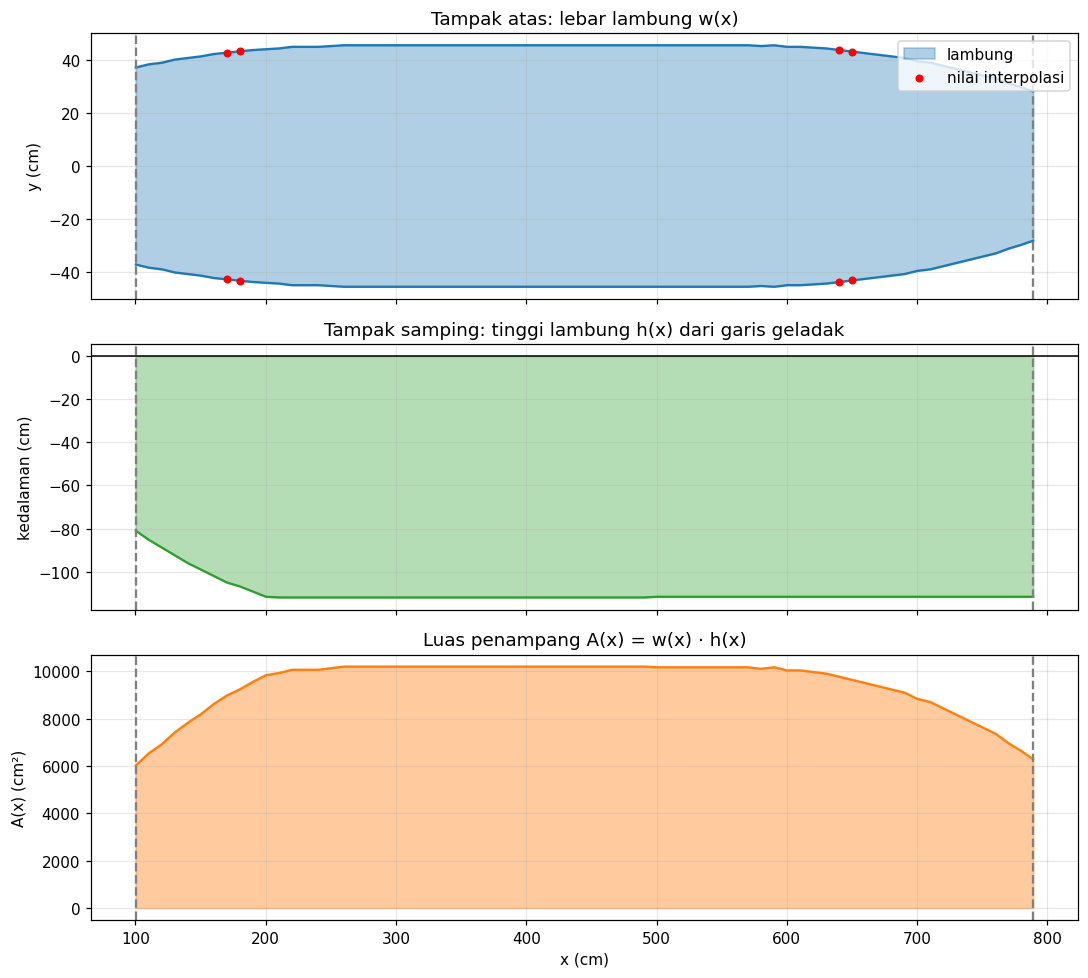

In [81]:
fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Tampak atas (simetris terhadap sumbu lambung)
ax[0].fill_between(x, -w/2, w/2, color="tab:blue", alpha=0.35, label="lambung")
ax[0].plot(x, w/2, color="tab:blue"); ax[0].plot(x, -w/2, color="tab:blue")
ax[0].scatter(x[hilang], w[hilang]/2, color="red", zorder=5, s=18, label="nilai interpolasi")
ax[0].scatter(x[hilang], -w[hilang]/2, color="red", zorder=5, s=18)
ax[0].set_ylabel("y (cm)"); ax[0].set_title("Tampak atas: lebar lambung w(x)")
ax[0].set_aspect("auto"); ax[0].legend(loc="upper right")

# Tampak samping
ax[1].fill_between(x, 0, -h, color="tab:green", alpha=0.35)
ax[1].plot(x, -h, color="tab:green"); ax[1].axhline(0, color="k", lw=1)
ax[1].set_ylabel("kedalaman (cm)"); ax[1].set_title("Tampak samping: tinggi lambung h(x) dari garis geladak")

# Luas penampang
A_data = w * h
ax[2].fill_between(x, 0, A_data, color="tab:orange", alpha=0.4)
ax[2].plot(x, A_data, color="tab:orange")
ax[2].set_ylabel("A(x) (cm²)"); ax[2].set_xlabel("x (cm)")
ax[2].set_title("Luas penampang A(x) = w(x) · h(x)")

for k in range(3):
    ax[k].axvline(a, color="gray", ls="--"); ax[k].axvline(b, color="gray", ls="--")
plt.tight_layout(); plt.show()

## 6. Metode Numerik

Integral yang dihitung adalah $V=\int_a^b A(x)\,dx$ dengan $A(x)=w(x)h(x)$. Saya menggunakan beberapa metode agar hasilnya bisa saling diverifikasi.

### 6.1 Aturan Trapesium Komposit
Untuk titik $x_0<x_1<\dots<x_n$ (jarak boleh tidak seragam),

$$\int_a^b A(x)\,dx \approx \sum_{i=0}^{n-1}\frac{x_{i+1}-x_i}{2}\,\big(A_i + A_{i+1}\big),$$

dengan galat $O(\Delta x^2)$. Metode ini dapat langsung dipakai pada data hasil digitasi, termasuk selang terakhir yang lebih pendek.

### 6.2 Aturan Simpson 1/3 Komposit
Untuk jarak seragam $\Delta x$ dan jumlah selang $N$ **genap**,

$$\int_a^b A(x)\,dx \approx \frac{\Delta x}{3}\Big[A_0 + 4\!\!\sum_{i\ \text{ganjil}}\!\! A_i + 2\!\!\sum_{i\ \text{genap}}\!\! A_i + A_N\Big],$$

dengan galat $O(\Delta x^4)$ untuk fungsi yang cukup mulus. Karena jarak data hasil digitasi tidak seragam di selang terakhir, Simpson dipakai pada grid seragam yang dievaluasi dari fungsi interpolasi.

### 6.3 Interpolasi PCHIP dan *Adaptive Quadrature*
Data $w_i$ dan $h_i$ diinterpolasi dengan **PCHIP** (*Piecewise Cubic Hermite Interpolating Polynomial*). PCHIP menjaga sifat monoton data dan **tidak menimbulkan *overshoot*** di sekitar transisi dari bagian lengkung ke bagian datar, hal yang bisa terjadi pada spline kubik biasa. Integral $\int A(x)dx$ kemudian dihitung dengan `scipy.integrate.quad` (*adaptive Gauss-Kronrod*) sebagai **nilai acuan**. Sebagai pembanding, saya juga memakai spline kubik (`CubicSpline`).

In [82]:
def trapezoid(xv, yv):
    """Aturan trapesium komposit (jarak boleh tidak seragam)."""
    xv, yv = np.asarray(xv, float), np.asarray(yv, float)
    return float(np.sum(np.diff(xv) * (yv[1:] + yv[:-1]) / 2.0))

def simpson(xv, yv):
    """Aturan Simpson 1/3 komposit; jarak harus seragam dan jumlah selang genap."""
    xv, yv = np.asarray(xv, float), np.asarray(yv, float)
    n = len(xv) - 1
    if n % 2 != 0:
        raise ValueError("Simpson 1/3 butuh jumlah selang genap.")
    if not np.allclose(np.diff(xv), (xv[-1] - xv[0]) / n):
        raise ValueError("Simpson 1/3 butuh jarak titik seragam.")
    dx = (xv[-1] - xv[0]) / n
    return float(dx / 3.0 * (yv[0] + yv[-1] + 4.0 * yv[1:-1:2].sum() + 2.0 * yv[2:-1:2].sum()))

# Uji kedua fungsi pada integral yang jawabannya diketahui: integral x^2 dari 0 s.d. 3 = 9
xt = np.linspace(0, 3, 7)
print("Uji integral x^2 pada [0,3] (eksak = 9):")
print("   Trapesium :", trapezoid(xt, xt**2))
print("   Simpson   :", simpson(xt, xt**2))

Uji integral x^2 pada [0,3] (eksak = 9):
   Trapesium : 9.125
   Simpson   : 9.0


In [83]:
# Fungsi interpolasi
w_p, h_p = PchipInterpolator(x, w), PchipInterpolator(x, h)
w_c, h_c = CubicSpline(x, w),       CubicSpline(x, h)

A_pchip  = lambda t: float(w_p(t) * h_p(t))
A_cspl   = lambda t: float(w_c(t) * h_c(t))

# (1) Trapesium langsung pada data diskret (jarak tidak seragam)
V_trap_data = trapezoid(x, w * h)

# (2) Acuan: adaptive quadrature pada interpolasi PCHIP
#     (points=simpul data: integran adalah kubik mulus di tiap selang, sehingga hasilnya sangat akurat)
V_ref, galat_ref = quad(A_pchip, a, b, points=list(x[1:-1]), limit=500, epsabs=1e-3, epsrel=1e-9)

# (3) Simpson 1/3 dan Trapesium pada grid seragam (langkah ~ 5 cm) dari interpolasi PCHIP
N = 2 * int(round((b - a) / 5.0 / 2))      # jumlah selang genap
xs = np.linspace(a, b, N + 1)
As = w_p(xs) * h_p(xs)
V_simp = simpson(xs, As)
V_trap_fine = trapezoid(xs, As)

# (4) Pembanding: spline kubik
V_cspl, _ = quad(A_cspl, a, b, points=list(x[1:-1]), limit=500, epsabs=1e-3, epsrel=1e-9)

metode = [
    ("Trapesium (data langsung, 70 titik)", V_trap_data),
    (f"Trapesium (PCHIP, N={N})",           V_trap_fine),
    (f"Simpson 1/3 (PCHIP, N={N})",         V_simp),
    ("Adaptive quad (PCHIP) [acuan]",       V_ref),
    ("Adaptive quad (spline kubik)",        V_cspl),
]
tab = pd.DataFrame({
    "Metode": [m for m, _ in metode],
    "V (cm3)": [v for _, v in metode],
    "V (m3)": [v / 1e6 for _, v in metode],
    "V (liter)": [v / 1e3 for _, v in metode],
    "Selisih thd acuan (%)": [100 * (v - V_ref) / V_ref for _, v in metode],
})
pd.options.display.float_format = "{:,.4f}".format
print("Volume SATU lambung (di antara kedua sekat reserve buoyancy):\n")
print(tab.to_string(index=False))

Volume SATU lambung (di antara kedua sekat reserve buoyancy):

                             Metode        V (cm3)  V (m3)  V (liter)  Selisih thd acuan (%)
Trapesium (data langsung, 70 titik) 6,527,824.6320  6.5278 6,527.8246                -0.0124
           Trapesium (PCHIP, N=138) 6,528,406.5031  6.5284 6,528.4065                -0.0034
         Simpson 1/3 (PCHIP, N=138) 6,528,648.5943  6.5286 6,528.6486                 0.0003
      Adaptive quad (PCHIP) [acuan] 6,528,630.9808  6.5286 6,528.6310                 0.0000
       Adaptive quad (spline kubik) 6,528,773.5035  6.5288 6,528.7735                 0.0022


### 6.4 Pembanding Independen: Fungsi Bawaan SciPy

Sebagai pemeriksaan silang, integral yang sama dihitung dengan fungsi bawaan `scipy.integrate.trapezoid` dan `scipy.integrate.simpson` langsung pada data diskret $A_i = w_i h_i$. Fungsi diimpor dengan nama alias supaya tidak menimpa fungsi buatan sendiri di atas. `simpson` milik SciPy dapat menangani jumlah selang ganjil dan jarak tidak seragam (data ini punya 69 selang dan selang terakhir lebih pendek).

In [84]:
from scipy.integrate import trapezoid as sp_trapezoid, simpson as sp_simpson

# Luas penampang A(x) dalam cm^2
A = w * h

# 1. Metode Trapesium (SciPy)
V_1_trap = sp_trapezoid(A, x)            # cm^3
V_total_trap = 2 * V_1_trap / 1e6        # m^3

# 2. Metode Simpson 1/3 (SciPy)
V_1_simp = sp_simpson(A, x=x)            # cm^3
V_total_simp = 2 * V_1_simp / 1e6        # m^3

print(f"Volume Total (Trapesium)  : {V_total_trap:.4f} m^3 (1 lambung: {V_1_trap/1e6:.4f} m^3)")
print(f"Volume Total (Simpson 1/3): {V_total_simp:.4f} m^3 (1 lambung: {V_1_simp/1e6:.4f} m^3)")
print(f"\nSelisih Simpson - Trapesium: {V_1_simp - V_1_trap:,.1f} cm^3 per lambung "
      f"({100*(V_1_simp - V_1_trap)/V_1_trap:.4f} %)")
print(f"Cocok dengan fungsi buatan sendiri (trapesium data langsung)? {np.isclose(V_1_trap, V_trap_data)}")

Volume Total (Trapesium)  : 13.0556 m^3 (1 lambung: 6.5278 m^3)
Volume Total (Simpson 1/3): 13.0587 m^3 (1 lambung: 6.5293 m^3)

Selisih Simpson - Trapesium: 1,511.8 cm^3 per lambung (0.0232 %)
Cocok dengan fungsi buatan sendiri (trapesium data langsung)? True


### 6.5 Penanganan Selang Terakhir pada Simpson 1/3 (Data Diskret)

Data punya 70 titik, jadi ada 69 selang: 68 selang pertama seragam ($\Delta x = 10$ cm) dan selang terakhir hanya $\Delta x \approx 8{,}8$ cm. Aturan Simpson 1/3 butuh selang **seragam** dan **berjumlah genap**, sehingga rumus standar tidak bisa dipakai langsung pada seluruh data. Solusi yang dipakai (**Opsi A**):

$$V \approx \underbrace{\frac{\Delta x}{3}\Big[A_0 + 4\!\!\sum_{\text{ganjil}}\!\! A_i + 2\!\!\sum_{\text{genap}}\!\! A_i + A_{68}\Big]}_{\text{Simpson 1/3 pada 68 selang seragam}} + \underbrace{\frac{x_{69}-x_{68}}{2}\,(A_{68}+A_{69})}_{\text{Trapesium pada selang terakhir}}.$$

Opsi lainnya (**Opsi B**) adalah mengintegrasikan fungsi interpolasi PCHIP pada grid seragam, seperti yang sudah dilakukan di bagian 6. Keduanya dibandingkan di bawah ini.

In [85]:
A_data = w * h

# Opsi A: Simpson 1/3 pada 68 selang seragam (x[0]..x[68]) + Trapesium pada selang terakhir
dx_seragam = np.diff(x[:-1])
assert np.allclose(dx_seragam, dx_seragam[0], atol=0.2), "68 selang pertama harus seragam"
x_u = np.linspace(x[0], x[-2], len(x) - 1)          # grid seragam (selisih < 0.2 cm dari data asli)
V_simp_bag1  = simpson(x_u, A_data[:-1])            # fungsi buatan sendiri (bagian 6)
V_trap_bag2  = (A_data[-2] + A_data[-1]) / 2 * (x[-1] - x[-2])
V_1_simpA    = V_simp_bag1 + V_trap_bag2

print(f"Banyak selang seragam      : {len(x_u) - 1} (genap: {(len(x_u) - 1) % 2 == 0})")
print(f"Selang terakhir            : {x[-1] - x[-2]:.1f} cm")
print(f"Simpson 68 selang          : {V_simp_bag1/1e6:.4f} m3")
print(f"Trapesium selang terakhir  : {V_trap_bag2/1e6:.4f} m3")
print(f"Simpson Opsi A (1 lambung) : {V_1_simpA/1e6:.4f} m3  -> total 2 lambung {2*V_1_simpA/1e6:.4f} m3")

perb = pd.DataFrame({
    "Metode": ["Trapesium (data, selang tak seragam)", "Simpson Opsi A (data: 68 selang + trapesium)",
               "Simpson SciPy (data)", "Simpson Opsi B (PCHIP, grid seragam)", "Adaptive quad (PCHIP) [acuan]"],
    "1 lambung (m3)": [V_trap_data/1e6, V_1_simpA/1e6, V_1_simp/1e6, V_simp/1e6, V_ref/1e6],
    "2 lambung (m3)": [2*V_trap_data/1e6, 2*V_1_simpA/1e6, 2*V_1_simp/1e6, 2*V_simp/1e6, 2*V_ref/1e6],
    "2 lambung (liter)": [2*V_trap_data/1e3, 2*V_1_simpA/1e3, 2*V_1_simp/1e3, 2*V_simp/1e3, 2*V_ref/1e3],
})
pd.options.display.float_format = "{:,.4f}".format
print()
print(perb.to_string(index=False))

Banyak selang seragam      : 68 (genap: True)
Selang terakhir            : 8.8 cm
Simpson 68 selang          : 6.4724 m3
Trapesium selang terakhir  : 0.0569 m3
Simpson Opsi A (1 lambung) : 6.5293 m3  -> total 2 lambung 13.0586 m3

                                      Metode  1 lambung (m3)  2 lambung (m3)  2 lambung (liter)
        Trapesium (data, selang tak seragam)          6.5278         13.0556        13,055.6493
Simpson Opsi A (data: 68 selang + trapesium)          6.5293         13.0586        13,058.6177
                        Simpson SciPy (data)          6.5293         13.0587        13,058.6728
        Simpson Opsi B (PCHIP, grid seragam)          6.5286         13.0573        13,057.2972
               Adaptive quad (PCHIP) [acuan]          6.5286         13.0573        13,057.2620


Semua metode memberikan hasil yang sangat berdekatan (selisih jauh di bawah 1%), sehingga hasil perhitungan konsisten. Perbedaan kecil antara trapesium dan Simpson wajar karena trapesium sedikit meremehkan/melebihkan area pada bagian yang melengkung, sedangkan Simpson mengakomodasi kelengkungan tersebut.

## 7. Verifikasi: Studi Konvergensi

Agar yakin bahwa angka yang diperoleh bukan kebetulan karena pemilihan jumlah selang, saya periksa **konvergensi** Trapesium dan Simpson terhadap nilai acuan (*adaptive quadrature*) saat jumlah selang $N$ diperbesar. Secara teori galat Trapesium turun sebanding $\Delta x^2$ (orde 2) dan Simpson sebanding $\Delta x^4$ (orde 4) bila integran cukup mulus. Karena PCHIP hanya kontinu sampai turunan pertama ($C^1$), orde Simpson yang teramati dapat lebih rendah dari 4, tetapi tetap lebih baik daripada Trapesium.

  N  dx (cm)    V Trapesium      V Simpson  |galat| Trap  |galat| Simp  orde Trap  orde Simp
  2 344.4000 5,636,312.6400 6,100,674.0480  892,318.3408  427,956.9328        NaN        NaN
  4 172.2000 6,298,351.9300 6,519,031.6934  230,279.0508    9,599.2875     1.9542     5.4784
  8  86.1000 6,474,751.4542 6,533,551.2956   53,879.5266    4,920.3148     2.0956     0.9642
 16  43.0500 6,511,381.5450 6,523,591.5752   17,249.4359    5,039.4056     1.6432    -0.0345
 32  21.5250 6,522,624.7830 6,526,372.5291    6,006.1978    2,258.4518     1.5220     1.1579
 64  10.7625 6,527,783.8290 6,529,503.5110      847.1518      872.5302     2.8258     1.3721
128   5.3813 6,528,392.1591 6,528,594.9358      238.8217       36.0450     1.8267     4.5973
256   2.6906 6,528,573.5364 6,528,633.9955       57.4444        3.0146     2.0557     3.5797
512   1.3453 6,528,616.3202 6,528,630.5815       14.6607        0.3994     1.9702     2.9161


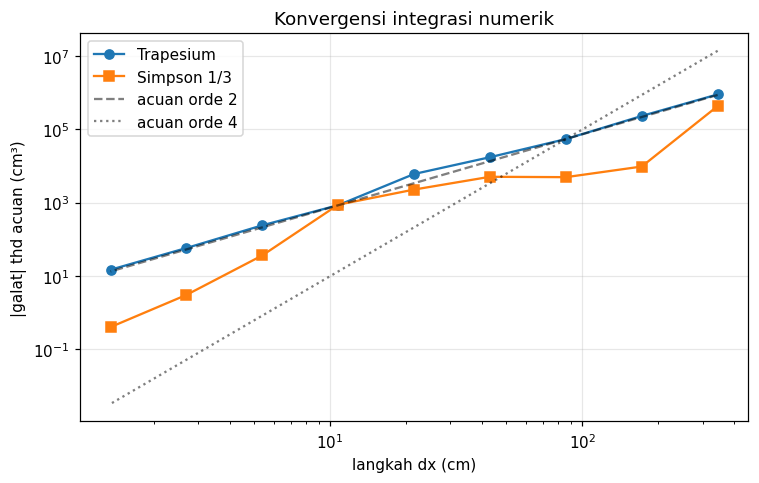


Pada N = 512 (dx = 1.35 cm): selisih Simpson thd acuan = 3.99e-01 cm3


In [86]:
Ns = [2, 4, 8, 16, 32, 64, 128, 256, 512]
rows_k = []
for n_ in Ns:
    xg = np.linspace(a, b, n_ + 1)
    Ag = w_p(xg) * h_p(xg)
    Vt, Vs = trapezoid(xg, Ag), simpson(xg, Ag)
    rows_k.append((n_, (b - a) / n_, Vt, Vs, abs(Vt - V_ref), abs(Vs - V_ref)))
kon = pd.DataFrame(rows_k, columns=["N", "dx (cm)", "V Trapesium", "V Simpson", "|galat| Trap", "|galat| Simp"])

# orde konvergensi teramati p = log2(e_N / e_2N)
def orde(e):
    p = [np.nan]
    for i in range(1, len(e)):
        p.append(np.log2(e[i-1] / e[i]) if e[i] > 1e-9 and e[i-1] > 1e-9 else np.nan)
    return p
kon["orde Trap"] = orde(kon["|galat| Trap"].values)
kon["orde Simp"] = orde(kon["|galat| Simp"].values)

pd.options.display.float_format = "{:,.4f}".format
print(kon.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(kon["dx (cm)"], np.maximum(kon["|galat| Trap"], 1e-6), "o-", label="Trapesium")
ax.loglog(kon["dx (cm)"], np.maximum(kon["|galat| Simp"], 1e-6), "s-", label="Simpson 1/3")
dxr = kon["dx (cm)"].values
ax.loglog(dxr, kon["|galat| Trap"].values[2] * (dxr / dxr[2])**2, "k--", alpha=.5, label="acuan orde 2")
ax.loglog(dxr, kon["|galat| Trap"].values[2] * (dxr / dxr[2])**4, "k:",  alpha=.5, label="acuan orde 4")
ax.set_xlabel("langkah dx (cm)"); ax.set_ylabel("|galat| thd acuan (cm³)")
ax.set_title("Konvergensi integrasi numerik"); ax.legend(); plt.tight_layout(); plt.show()

print(f"\nPada N = {Ns[-1]} (dx = {(b-a)/Ns[-1]:.2f} cm): selisih Simpson thd acuan = {kon['|galat| Simp'].iloc[-1]:.2e} cm3")

Pada $N$ kecil galat tidak turun secara monoton karena grid integrasi belum selaras dengan simpul-simpul interpolasi (jarak 10 cm), sehingga orde teramati masih berfluktuasi. Setelah $N\ge 128$, galat Trapesium turun dengan orde $\approx 2$ dan galat Simpson dengan orde $\approx 3$ sampai $4$, sesuai teori; keduanya menuju nilai acuan yang sama dan Simpson jauh lebih kecil galatnya (pada $N=512$ hanya sekitar $0{,}4\ \text{cm}^3$ dari $6{,}5\times10^6\ \text{cm}^3$). Artinya **galat integrasi numerik sudah dapat diabaikan** dibandingkan dengan galat pengukuran dari gambar (dibahas pada bagian 8). Dengan kata lain, sumber ketidakpastian utama hasil ini bukan metode numeriknya, melainkan keterbatasan resolusi gambar.

## 8. Analisis Ketidakpastian

Data berasal dari gambar beresolusi terbatas, jadi hasil perlu dilengkapi dengan estimasi ketidakpastian. Ada tiga sumber yang saya tinjau:

1. **Galat posisi tepi kontur.** Satu piksel setara 0,6 cm. Lebar dan tinggi masing-masing ditentukan dari dua tepi, sehingga kasus terburuk saya anggap $\delta w=\delta h = 2$ piksel $=1{,}2$ cm. Batas bawah/atas volume: $\int (w\mp\delta)(h\mp\delta)\,dx$.
2. **Simulasi Monte Carlo.** Setiap sampel $w_i$ dan $h_i$ diberi derau acak independen berdistribusi normal dengan simpangan baku 1 piksel (0,6 cm) sebanyak 5000 kali. Ini memberi gambaran sebaran hasil bila galat bersifat acak.
3. **Galat skala.** Jika periode dash meleset ±1%, volume (dimensi panjang pangkat tiga) meleset sekitar ±3%.

Volume nominal (trapesium)       : 6.5278 m3
(1) Kasus terburuk (+-1.2 cm)    : 6.3668 s.d. 6.6908 m3   (-2.5% / +2.5%)
(2) Monte Carlo (5000 simulasi)  : rata-rata 6.5278 m3, simpangan baku 0.0068 m3 (0.10%)
(3) Galat skala +-1%             : 6.3339 s.d. 6.7256 m3   (+-3%)


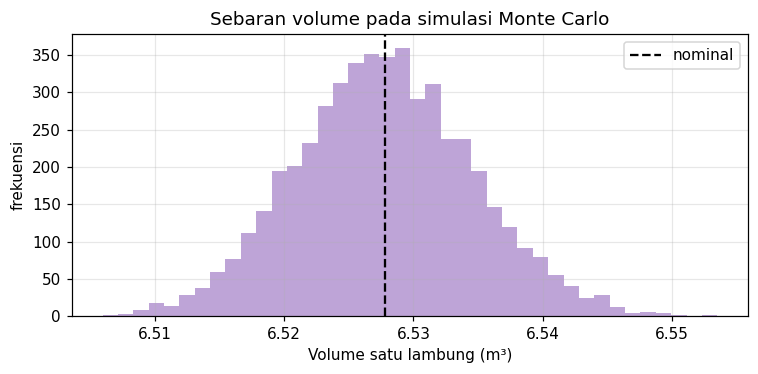

In [87]:
def vol(wv, hv):
    return trapezoid(x, wv * hv)

V_nom = vol(w, h)

# (1) Kasus terburuk: tepi meleset 2 piksel
delta = 2 * CM_PER_PX
V_lo, V_hi = vol(w - delta, h - delta), vol(w + delta, h + delta)

# (2) Monte Carlo (derau 1 piksel, independen)
rng = np.random.default_rng(42)
sim = np.array([vol(w + rng.normal(0, CM_PER_PX, len(x)), h + rng.normal(0, CM_PER_PX, len(x))) for _ in range(5000)])

# (3) Galat skala +-1%
V_s_lo, V_s_hi = V_nom * 0.99**3, V_nom * 1.01**3

print(f"Volume nominal (trapesium)       : {V_nom/1e6:.4f} m3")
print(f"(1) Kasus terburuk (+-{delta:.1f} cm)    : {V_lo/1e6:.4f} s.d. {V_hi/1e6:.4f} m3   "
      f"({100*(V_lo-V_nom)/V_nom:+.1f}% / {100*(V_hi-V_nom)/V_nom:+.1f}%)")
print(f"(2) Monte Carlo (5000 simulasi)  : rata-rata {sim.mean()/1e6:.4f} m3, simpangan baku {sim.std()/1e6:.4f} m3 "
      f"({100*sim.std()/sim.mean():.2f}%)")
print(f"(3) Galat skala +-1%             : {V_s_lo/1e6:.4f} s.d. {V_s_hi/1e6:.4f} m3   (+-3%)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(sim / 1e6, bins=40, color="tab:purple", alpha=.6)
ax.axvline(V_nom / 1e6, color="k", ls="--", label="nominal")
ax.set_xlabel("Volume satu lambung (m³)"); ax.set_ylabel("frekuensi")
ax.set_title("Sebaran volume pada simulasi Monte Carlo"); ax.legend(); plt.tight_layout(); plt.show()

Derau acak per piksel hampir saling meniadakan saat diintegrasikan (simpangan baku sangat kecil). Yang lebih menentukan adalah **galat sistematis**, yakni posisi tepi kontur (kasus terburuk) dan skala gambar. Maka ketidakpastian realistis hasil ini sekitar **±3 s.d. ±5%**, dan nilai tersebut sudah cukup memadai untuk perhitungan dari gambar teknik.

## 9. Pemeriksaan Kewajaran (*Sanity Check*)

Sebagai pemeriksaan kasar, bandingkan volume lambung dengan **balok pembatas** berukuran panjang efektif × lebar maksimum × tinggi maksimum. Rasionya disebut **koefisien blok** $C_b$. Nilainya harus berada di antara 0 dan 1. Karena penampang dianggap persegi panjang dan sebagian besar panjang lambung (sekitar 4 m di tengah) berpenampang konstan, nilai yang tinggi (sekitar 0,9) memang wajar; pengurangannya hanya berasal dari penyempitan dan naiknya dasar di dekat kedua sekat.

In [88]:
L_eff, W_max, H_max = b - a, w.max(), h.max()
V_box = L_eff * W_max * H_max
Cb = V_ref / V_box

print(f"Panjang efektif L = {L_eff:.1f} cm")
print(f"Lebar maks W      = {W_max:.1f} cm")
print(f"Tinggi maks H     = {H_max:.1f} cm")
print(f"Volume balok L·W·H = {V_box/1e6:.4f} m3")
print(f"Volume lambung     = {V_ref/1e6:.4f} m3")
print(f"Koefisien blok Cb  = {Cb:.3f}  ->", "wajar (0 < Cb < 1)" if 0 < Cb < 1 else "TIDAK wajar")

Panjang efektif L = 688.8 cm
Lebar maks W      = 91.2 cm
Tinggi maks H     = 111.9 cm
Volume balok L·W·H = 7.0294 m3
Volume lambung     = 6.5286 m3
Koefisien blok Cb  = 0.929  -> wajar (0 < Cb < 1)


### 9.1 Apakah Kedua Lambung Identik?

Model $V_{\text{total}} = 2V_{\text{lambung}}$ mengandaikan kedua lambung identik. Hal ini diperiksa dengan membandingkan hasil pengukuran piksel pada lambung atas dan lambung bawah di tampak atas (nilai hasil ekstraksi kontur yang sama seperti pada bagian 4).

In [89]:
# Hasil pengukuran piksel tiap lambung pada tampak atas (koordinat acuan 1456 px, lalu dikonversi ke cm)
CM_PER_REFPX = CM_PER_PX * 2205 / 1456       # 1 px acuan = 0.9086 cm
ukur = pd.DataFrame({
    "Besaran": ["Lebar zona tengah (cm)", "Posisi ujung haluan (cm)", "Posisi ujung buritan (cm)"],
    "Lambung atas":  [91.2, 1011.6 * CM_PER_REFPX, 19.1 * CM_PER_REFPX],
    "Lambung bawah": [91.2, 1011.6 * CM_PER_REFPX, 21.8 * CM_PER_REFPX],
})
ukur["Selisih (cm)"] = (ukur["Lambung atas"] - ukur["Lambung bawah"]).abs()
pd.options.display.float_format = "{:,.1f}".format
print(ukur.to_string(index=False))
print("\nLebar dan posisi ujung haluan kedua lambung sama. Selisih kecil hanya pada ujung buritan,")
print("yang berada di dalam daerah reserve buoyancy (tidak dihitung). Jadi V_total = 2 x V_lambung.")

                  Besaran  Lambung atas  Lambung bawah  Selisih (cm)
   Lebar zona tengah (cm)          91.2           91.2           0.0
 Posisi ujung haluan (cm)         919.2          919.2           0.0
Posisi ujung buritan (cm)          17.4           19.8           2.5

Lebar dan posisi ujung haluan kedua lambung sama. Selisih kecil hanya pada ujung buritan,
yang berada di dalam daerah reserve buoyancy (tidak dihitung). Jadi V_total = 2 x V_lambung.


## 10. Hasil Akhir

In [90]:
V1 = V_ref                      # nilai acuan (adaptive quadrature pada interpolasi PCHIP)
V_tot = 2 * V1
ketidakpastian = 0.05           # +-5% (lihat bagian 8)

hasil = pd.DataFrame({
    "Besaran": ["Volume satu lambung", "Volume kedua lambung (total)"],
    "cm3": [V1, V_tot],
    "m3": [V1 / 1e6, V_tot / 1e6],
    "liter": [V1 / 1e3, V_tot / 1e3],
})
pd.options.display.float_format = "{:,.3f}".format
print(hasil.to_string(index=False))

print("\n" + "=" * 60)
print(f"Volume satu lambung    = {V1/1e6:.2f} m3  (+-{100*ketidakpastian:.0f}%  ->  {V1*(1-ketidakpastian)/1e6:.2f} s.d. {V1*(1+ketidakpastian)/1e6:.2f} m3)")
print(f"Volume KEDUA lambung   = {V_tot/1e6:.2f} m3  (+-{100*ketidakpastian:.0f}%  ->  {V_tot*(1-ketidakpastian)/1e6:.2f} s.d. {V_tot*(1+ketidakpastian)/1e6:.2f} m3)")
print("=" * 60)

                     Besaran            cm3     m3      liter
         Volume satu lambung  6,528,630.981  6.529  6,528.631
Volume kedua lambung (total) 13,057,261.962 13.057 13,057.262

Volume satu lambung    = 6.53 m3  (+-5%  ->  6.20 s.d. 6.86 m3)
Volume KEDUA lambung   = 13.06 m3  (+-5%  ->  12.40 s.d. 13.71 m3)


## 11. Kesimpulan

1. Volume lambung dimodelkan sebagai $V=\int_a^b w(x)h(x)\,dx$ dengan $w(x)$ dari tampak atas dan $h(x)$ dari tampak samping. Ini sesuai asumsi soal bahwa lantai datar sehingga setiap penampang berupa persegi panjang. Batas integrasi $a$ dan $b$ adalah sekat *reserve buoyancy*, sehingga volume *reserve buoyancy* tidak ikut dihitung.
2. Skala gambar ditentukan dari periode dash (10 cm $\approx$ 16,67 piksel pada 200 dpi), bukan dari jarak antar garis grid, karena satu kotak grid ternyata kira-kira 42,7 cm.
3. Panjang total lambung sekitar 9 m, dengan lebar maksimum sekitar 91 cm dan tinggi maksimum sekitar 112 cm. Panjang efektif di antara kedua sekat sekitar 6,9 m.
4. Lima variasi metode integrasi (Trapesium, Simpson 1/3, dan *adaptive quadrature* dengan interpolasi PCHIP maupun spline kubik) memberi hasil yang saling konsisten, dan studi konvergensi memperlihatkan galat numeriknya sangat kecil.
5. **Volume satu lambung ≈ 6,53 m³ dan volume kedua lambung ≈ 13,06 m³ (sekitar 13.057 liter)**, dengan ketidakpastian sekitar ±5% yang terutama berasal dari resolusi gambar dan skala, bukan dari metode numerik.

**Perbandingan Trapesium dan Simpson.** Pada data diskret, Trapesium menghasilkan 6,5278 m³ per lambung (13,0556 m³ untuk kedua lambung), sedangkan Simpson 1/3 menghasilkan 6,5293 m³ (13,0587 m³). Selisihnya hanya sekitar 1.512 cm³ (±1,5 liter) per lambung atau 0,023%. Simpson sedikit lebih besar karena ia memakai pendekatan parabola yang mengikuti kelengkungan $A(x)$ di dekat kedua sekat, sedangkan Trapesium yang memakai ruas lurus cenderung sedikit meremehkan area pada bagian cekung. Selang terakhir yang lebih pendek (8,8 cm) ditangani dengan Simpson pada 68 selang seragam ditambah Trapesium pada selang terakhir (Opsi A, 6,5293 m³), dan hasilnya sama dengan fungsi SciPy maupun Simpson pada interpolasi PCHIP (Opsi B, 6,5286 m³) dengan selisih di bawah 0,02%. Nilai acuan (*adaptive quadrature* pada interpolasi PCHIP), yaitu 6,5286 m³, berada di antara keduanya, dan hasil fungsi bawaan SciPy identik dengan fungsi buatan sendiri.

**Kesimpulan akhir.** Selisih antarmetode (0,02%) jauh lebih kecil daripada ketidakpastian akibat resolusi gambar dan skala (±3 sampai ±5%), sehingga pilihan metode tidak mengubah jawaban. Maka volume satu lambung adalah **≈ 6,53 m³** dan volume kedua lambung adalah **≈ 13,06 m³**.

**Keterbatasan.** Hasil bergantung pada ketelitian digitasi gambar beresolusi terbatas. Selain itu lambung dianggap berpenampang persegi panjang dengan dasar datar sesuai perintah soal; pada perahu sebenarnya, lambung berbentuk V atau bulat serta memiliki keel akan menghasilkan volume yang lebih kecil. Kedua lambung dianggap identik, sesuai dengan yang terlihat pada gambar.